In [1]:
from astropy.table import Table
from astropy.io import fits
import numpy as np
import pylab as plt
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.optimize as fitter
%matplotlib inline

## 1)

In [13]:
pd.read_csv('GlobalLandTemperaturesByState.csv')

,dt,AverageTemperature,AverageTemperatureUncertainty,State,Country
0,1855-05-01,25.544,1.171,Acre,Brazil
1,1855-06-01,24.228,1.103,Acre,Brazil
2,1855-07-01,24.371,1.044,Acre,Brazil
3,1855-08-01,25.427,1.073,Acre,Brazil
4,1855-09-01,25.675,1.014,Acre,Brazil
...,...,...,...,...,...
645670,2013-05-01,21.634,0.578,Zhejiang,China
645671,2013-06-01,24.679,0.596,Zhejiang,China
645672,2013-07-01,29.272,1.340,Zhejiang,China
645673,2013-08-01,29.202,0.869,Zhejiang,China


In [23]:
df = pd.read_csv('GlobalLandTemperaturesByState.csv')
df_filtered = df[['dt', 'AverageTemperature', 'State']]

df_filtered['dt'] = pd.to_datetime(df_filtered['dt'])
df_filtered = df_filtered[df_filtered['dt'].dt.year > 2000]

df_filtered = df_filtered[df_filtered['State'].isin(['Wyoming', 'Nebraska', 'South Dakota'])]

print(df_filtered.shape)

print(df_filtered.head())

(459, 3)
               dt  AverageTemperature     State
350773 2001-01-01              -2.592  Nebraska
350774 2001-02-01              -5.575  Nebraska
350775 2001-03-01               2.077  Nebraska
350776 2001-04-01              10.431  Nebraska
350777 2001-05-01              15.878  Nebraska


/var/folders/2r/nm7d6kn54ds20lxjvmbvw65c0000gn/T/ipykernel_28884/2893355980.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['dt'] = pd.to_datetime(df_filtered['dt'])


In [25]:
df_avg_temp = df_filtered.groupby('dt')['AverageTemperature'].mean().reset_index()

print(df_avg_temp.head())

          dt  AverageTemperature
0 2001-01-01           -4.480333
1 2001-02-01           -7.541000
2 2001-03-01            0.590333
3 2001-04-01            7.889000
4 2001-05-01           13.908667


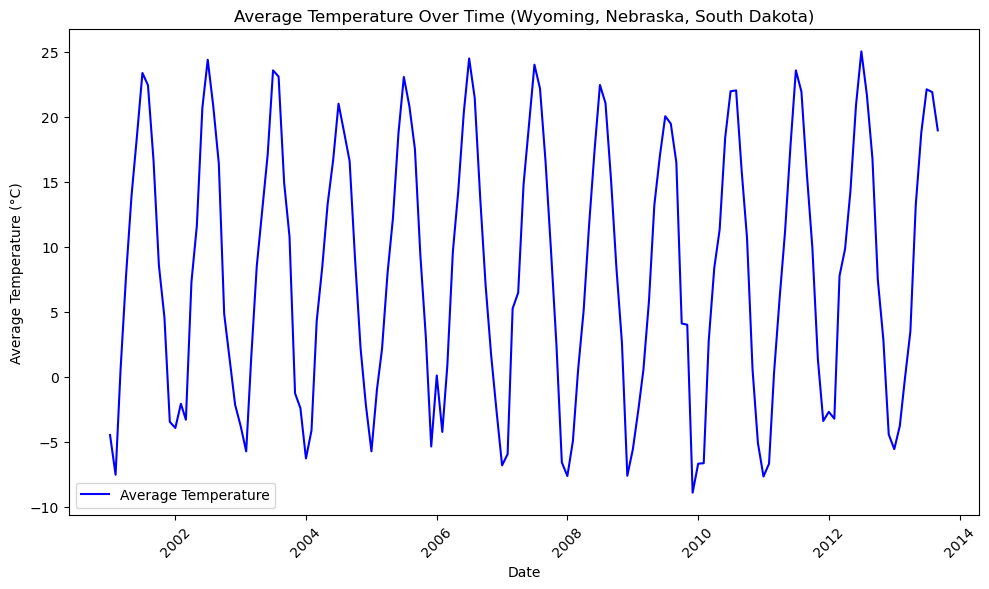

In [30]:
plt.figure(figsize=(10, 6))
plt.plot(df_avg_temp['dt'], df_avg_temp['AverageTemperature'], label='Average Temperature', color='b')

plt.xlabel('Date')
plt.ylabel('Average Temperature (°C)')
plt.title('Average Temperature Over Time (Wyoming, Nebraska, South Dakota)')
plt.xticks(rotation=45)  
plt.tight_layout() 
plt.legend()
plt.show()

In [32]:
df_avg_temp['dt'] = pd.to_datetime(df_avg_temp['dt'])
reference_date = pd.to_datetime('2000-01-01')
df_avg_temp['date_numeric'] = (df_avg_temp['dt'] - reference_date).dt.days

print(df_avg_temp[['dt', 'AverageTemperature', 'date_numeric']].head())

          dt  AverageTemperature  date_numeric
0 2001-01-01           -4.480333           366
1 2001-02-01           -7.541000           397
2 2001-03-01            0.590333           425
3 2001-04-01            7.889000           456
4 2001-05-01           13.908667           486


In [36]:
from scipy.optimize import curve_fit
def model(x, A, B, C, D):
    return A * np.cos(B * x + C) + D

A_guess = (df_avg_temp['AverageTemperature'].max() - df_avg_temp['AverageTemperature'].min()) / 2
period_guess = 4  
B_guess = 2 * np.pi / period_guess  
C_guess = 0
D_guess = df_avg_temp['AverageTemperature'].mean()

initial_guess = [A_guess, B_guess, C_guess, D_guess]

x_data = df_avg_temp['date_numeric'].values  
y_data = df_avg_temp['AverageTemperature'].values  

params_opt, params_cov = curve_fit(model, x_data, y_data, p0=initial_guess)

print("Optimized parameters:", params_opt)

Optimized parameters: [0.77806466 1.57020721 2.56532615 8.18947086]


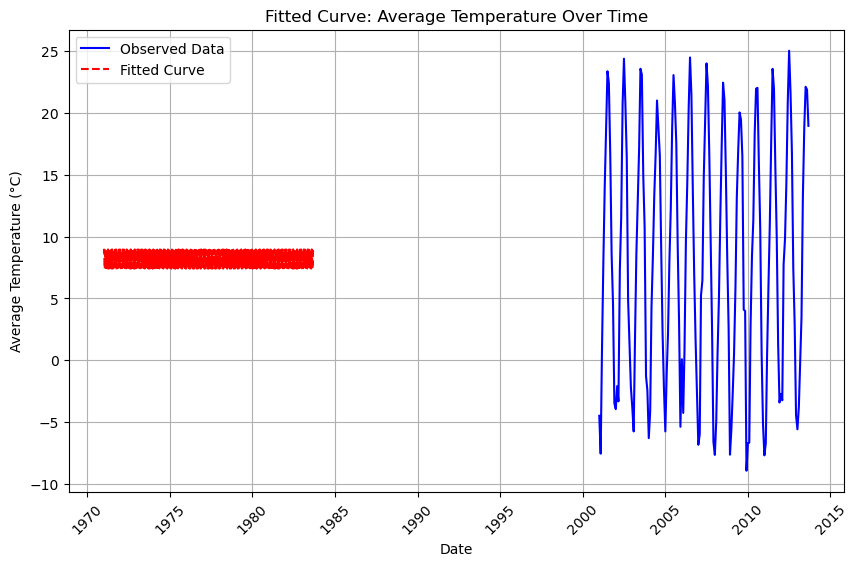

In [46]:
plt.figure(figsize=(10, 6))
plt.plot(df_avg_temp['dt'], df_avg_temp['AverageTemperature'], label='Observed Data', color='blue')

x_fitted = np.linspace(min(x_data), max(x_data), 1000) 
y_fitted = model(x_fitted, *params_opt)  

plt.plot(x_fitted, y_fitted, label='Fitted Curve', color='red', linestyle='--')
plt.xlabel('Date')
plt.ylabel('Average Temperature (°C)')
plt.title('Fitted Curve: Average Temperature Over Time')
plt.xticks(rotation=45)
plt.grid(True)
plt.legend()
plt.show()

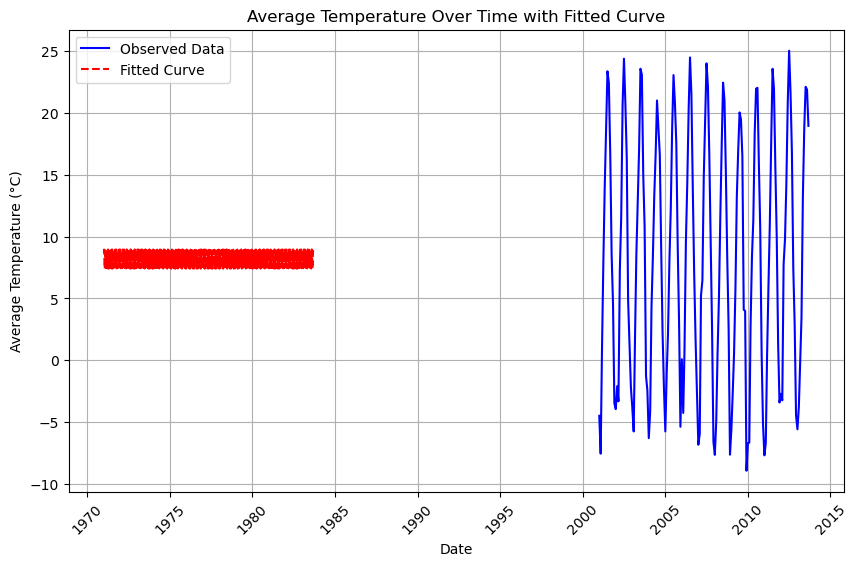

In [48]:
plt.figure(figsize=(10, 6))

plt.plot(df_avg_temp['dt'], df_avg_temp['AverageTemperature'], label='Observed Data', color='blue')

x_fitted = np.linspace(min(df_avg_temp['date_numeric'].values), max(df_avg_temp['date_numeric'].values), 1000)

y_fitted = model(x_fitted, *params_opt)

plt.plot(x_fitted, y_fitted, label='Fitted Curve', color='red', linestyle='--')

plt.xlabel('Date')
plt.ylabel('Average Temperature (°C)')
plt.title('Average Temperature Over Time with Fitted Curve')
plt.xticks(rotation=45)  
plt.grid(True)
plt.legend()  
plt.show()

In [52]:
params_opt, params_covariance = curve_fit(model, df_avg_temp['date_numeric'], df_avg_temp['AverageTemperature'], p0=[initial_guess])

errors = np.sqrt(np.diag(params_covariance))

print("Parameter Errors:")
for i, error in enumerate(errors):
    print(f"Parameter {i+1} error: {error}")

Parameter Errors:
Parameter 1 error: 1.1657536624922842
Parameter 2 error: 0.001123003827382837
Parameter 3 error: 3.3464462641381876
Parameter 4 error: 0.8266651486516232


In [54]:
print("Fitted Parameters and their Errors:")
for i, (param, error) in enumerate(zip(params_opt, errors)):
    print(f"Parameter {i+1}: {param:.4f} +/- {error:.4f}")

A, w, b, c = params_opt  # assuming 4 parameters
print("\nFinal Equation:")
print(f"y = {A:.4f} * sin({w:.4f} * x + {b:.4f}) + {c:.4f}")

Fitted Parameters and their Errors:
Parameter 1: 0.7781 +/- 1.1658
Parameter 2: 1.5702 +/- 0.0011
Parameter 3: 2.5653 +/- 3.3464
Parameter 4: 8.1895 +/- 0.8267

Final Equation:
y = 0.7781 * sin(1.5702 * x + 2.5653) + 8.1895


## 2)

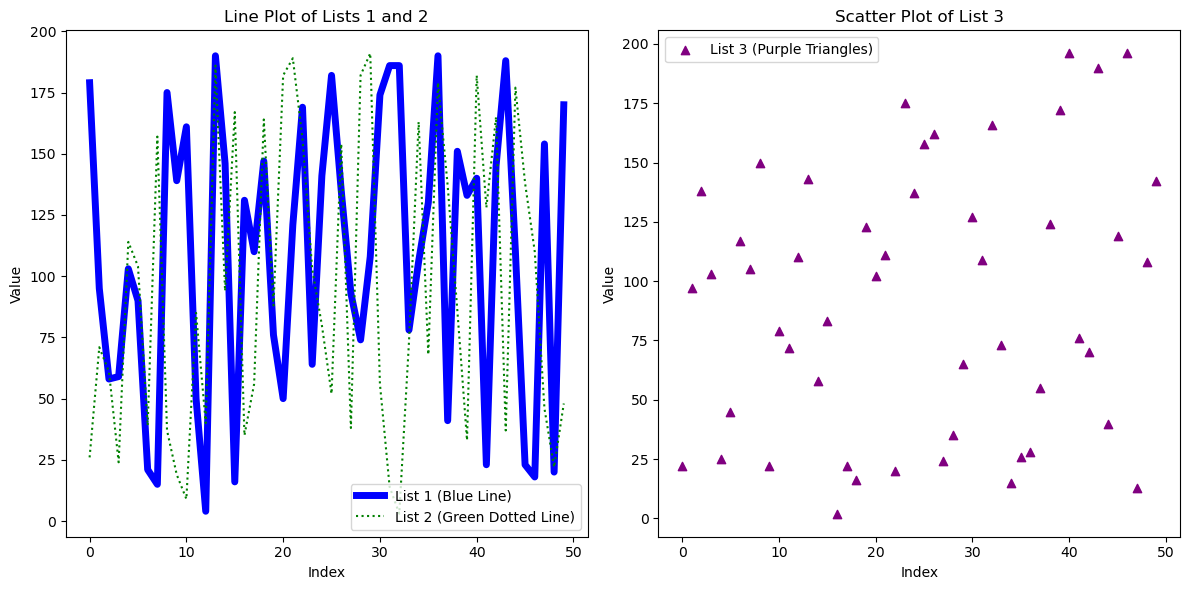

In [59]:
list1 = np.random.randint(0, 201, 50) 
list2 = np.random.randint(0, 201, 50)  
list3 = np.random.randint(0, 201, 50) 

fig, axs = plt.subplots(1, 2, figsize=(12, 6))

axs[0].plot(list1, color='blue', linewidth=5, label='List 1 (Blue Line)')
axs[0].plot(list2, color='green', linestyle=':', label='List 2 (Green Dotted Line)')

axs[0].set_title('Line Plot of Lists 1 and 2')
axs[0].set_xlabel('Index')
axs[0].set_ylabel('Value')
axs[0].legend()

axs[1].scatter(range(len(list3)), list3, color='purple', marker='^', label='List 3 (Purple Triangles)')

axs[1].set_title('Scatter Plot of List 3')
axs[1].set_xlabel('Index')
axs[1].set_ylabel('Value')
axs[1].legend()

plt.tight_layout()
plt.show()

## 3)

Estimate of pi for N=10: 3.2
Estimate of pi for N=1000: 3.08
Estimate of pi for N=100000: 3.15524
Estimate of pi for N=1000000: 3.143772


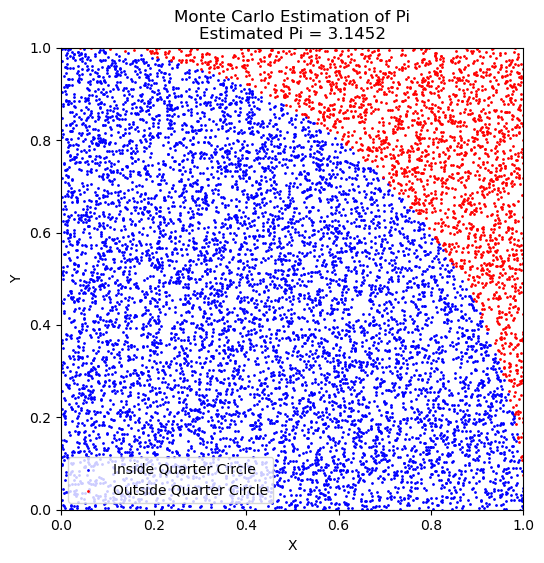

In [62]:
def estimate_pi(N):
    x = np.random.random(N)
    y = np.random.random(N)
    
    distance = x**2 + y**2
    
    inside_circle = distance <= 1
    
    pi_estimate = 4 * np.sum(inside_circle) / N
    return pi_estimate, x, y, inside_circle

for N in [10, 10**3, 10**5, 10**6]:
    pi_estimate, _, _, _ = estimate_pi(N)
    print(f"Estimate of pi for N={N}: {pi_estimate}")

N = 10**4
pi_estimate, x, y, inside_circle = estimate_pi(N)

plt.figure(figsize=(6,6))
plt.scatter(x[inside_circle], y[inside_circle], color='blue', s=1, label='Inside Quarter Circle')
plt.scatter(x[~inside_circle], y[~inside_circle], color='red', s=1, label='Outside Quarter Circle')


plt.xlim(0, 1)
plt.ylim(0, 1)
plt.gca().set_aspect('equal', adjustable='box')
plt.title(f"Monte Carlo Estimation of Pi\nEstimated Pi = {pi_estimate:.4f}")
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.show()